# ============================================
# 📊 Online Retail Analysis Project
# ============================================

# Autor: Jhan Daniel


# 📊 Online Retail Analysis

## 🧾 Introducción

Este proyecto analiza el comportamiento de ventas de un negocio de retail online, 
con el objetivo de identificar patrones de compra, tendencias temporales, 
clientes más valiosos y oportunidades de crecimiento.

El análisis se basa en datos transaccionales reales, incluyendo información 
sobre productos, clientes, fechas y países.

---

## 🎯 Objetivo

- Analizar la evolución de las ventas en el tiempo
- Identificar los países con mayor generación de ingresos
- Detectar los productos más vendidos
- Encontrar los clientes más valiosos
- Generar recomendaciones estratégicas basadas en datos

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [4]:
df = pd.read_csv('../data/online_retail.csv', encoding='ISO-8859-1')
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
# Eliminar nulos en clientes
df = df.dropna(subset=['CustomerID'])

# Convertir fecha
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Crear tipo de transacción (COMPRA / DEVOLUCIÓN)
df['TransactionType'] = df['Quantity'].apply(lambda x: 'Return' if x < 0 else 'Purchase')

# Cantidad absoluta
df['AbsQuantity'] = df['Quantity'].abs()

# Total de venta
df['TotalPrice'] = df['AbsQuantity'] * df['UnitPrice']

In [13]:
# Crear columnas útiles
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.strftime('%B')
df['Day'] = df['InvoiceDate'].dt.day

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,AbsQuantity,TotalPrice,Year,Month,MonthName,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Purchase,6,15.30,2010,12,December,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Purchase,6,20.34,2010,12,December,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Purchase,8,22.00,2010,12,December,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Purchase,6,20.34,2010,12,December,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Purchase,6,20.34,2010,12,December,1


In [56]:
monthly_sales = df['TotalPrice'].resample('MS').sum()
print(monthly_sales)

InvoiceDate
2010-12-01     590823.760
2011-01-01     663815.700
2011-02-01     457728.550
2011-03-01     611036.910
2011-04-01     512352.871
2011-05-01     708938.040
2011-06-01     714414.220
2011-07-01     625943.541
2011-08-01     674319.800
2011-09-01     974236.392
2011-10-01    1104033.990
2011-11-01    1191227.020
2011-12-01     693879.200
Freq: MS, Name: TotalPrice, dtype: float64


## 📈 Ventas Mensuales

A continuación, analizamos la evolución de las ventas a lo largo del tiempo 
para identificar tendencias y posibles patrones estacionales.

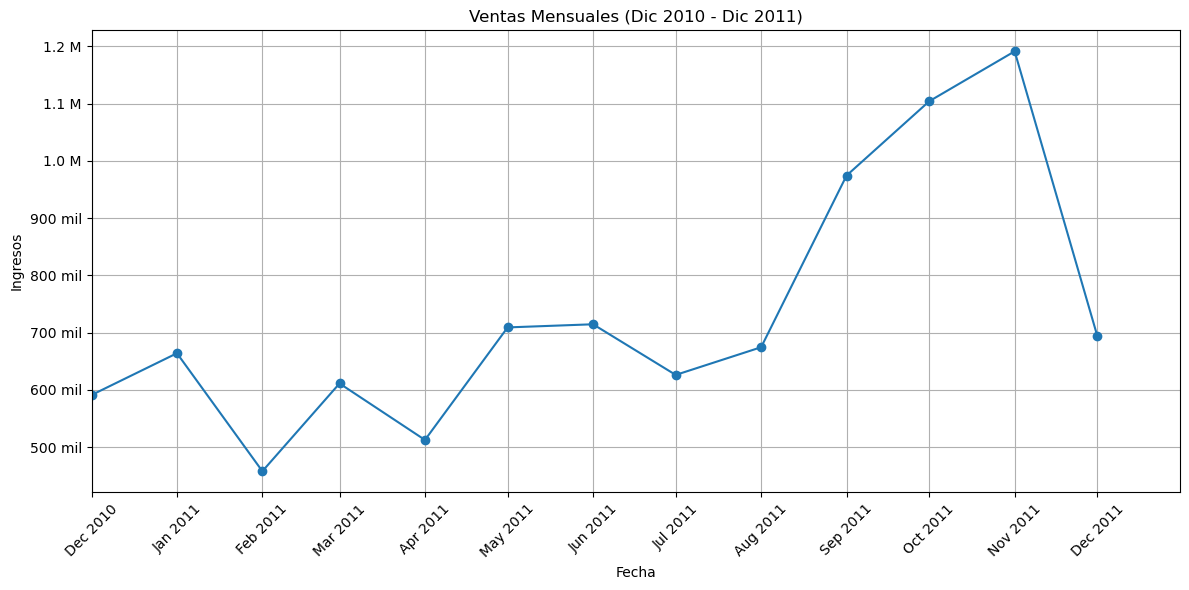

In [36]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, MonthLocator
import matplotlib.ticker as ticker
import pandas as pd
import os

# Asegurar índice datetime
df.index = pd.to_datetime(df.index)

# 🔥 CAMBIO AQUÍ (mejor usar MS)
monthly_sales = df['TotalPrice'].resample('MS').sum()

# Ordenar
monthly_sales = monthly_sales.sort_index()

# Filtrar periodo correcto
monthly_sales = monthly_sales.loc['2010-12':'2011-12']

# Crear carpeta
os.makedirs('../imagenes', exist_ok=True)

# Graficar
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Ventas Mensuales (Dic 2010 - Dic 2011)')
plt.xlabel('Fecha')
plt.ylabel('Ingresos')
plt.grid()

# 🔥 FIX EJE X
ax.xaxis.set_major_locator(MonthLocator(interval=1))
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

# 🔥 ESTE ES EL FIX CLAVE
ax.set_xlim(pd.Timestamp('2010-12-01'), pd.Timestamp('2011-12-31'))

# Formato eje Y
def formato_y(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f} M'
    elif x >= 1_000:
        return f'{int(x/1000)} mil'
    else:
        return str(int(x))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(formato_y))

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../imagenes/monthly_sales.png')
plt.show()

In [37]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(country_sales)

Country
United Kingdom    7848909.714
Netherlands        286231.140
EIRE               280806.580
Germany            236036.070
France             221335.260
Australia          139965.350
Spain               68379.640
Switzerland         57148.500
Belgium             41481.720
Sweden              40160.750
Name: TotalPrice, dtype: float64


## 🌍 Ventas por País top 10

En esta sección analizamos la distribución de las ventas por país, 
con el objetivo de identificar los mercados más importantes para el negocio.

Esto permite entender en qué regiones se concentra la mayor parte de los ingresos 
y detectar oportunidades de expansión en otros mercados.

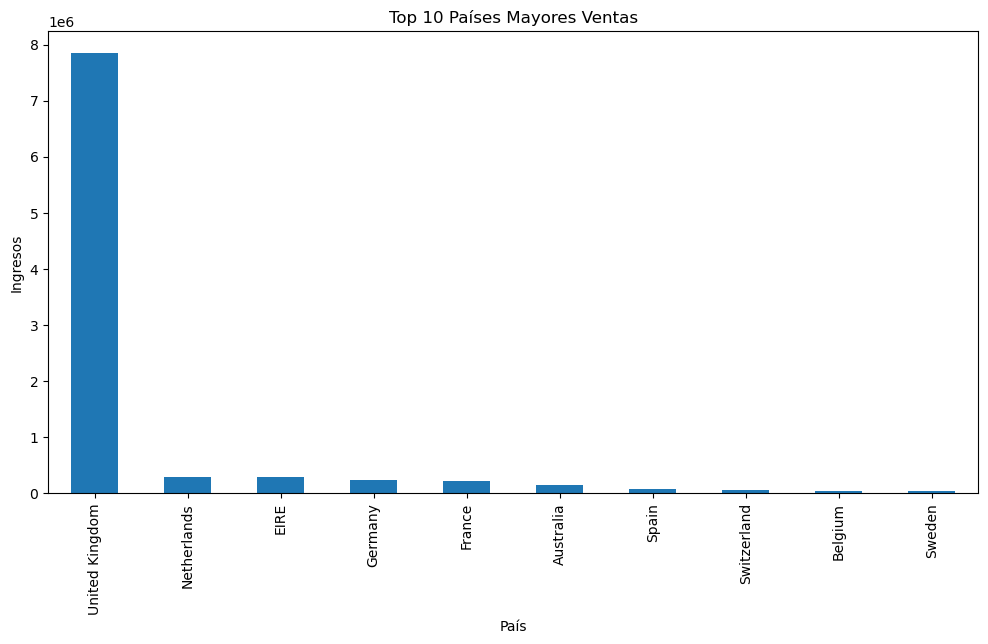

In [46]:
plt.figure(figsize=(12,6))
country_sales.plot(kind='bar')

plt.title('Top 10 Países Mayores Ventas')
plt.xlabel('País')
plt.ylabel('Ingresos')

plt.savefig('../imagenes/country_sales.png' , bbox_inches='tight')
plt.show()

In [39]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: Quantity, dtype: int64


## 🛍️ Productos Más Vendidos

A continuación, se analizan los productos con mayor volumen de ventas, 
con el fin de identificar cuáles generan mayor demanda.

Este análisis es clave para la gestión de inventario y la toma de decisiones comerciales.

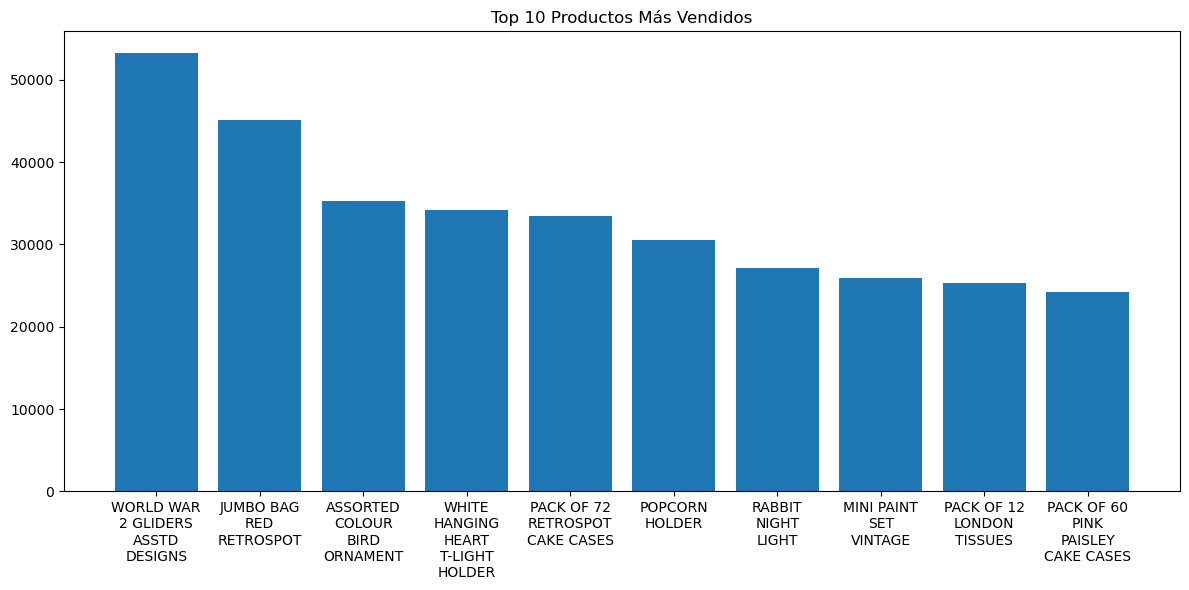

In [45]:
import textwrap

def wrap_labels(labels, width=10):
    return ['\n'.join(textwrap.wrap(label, width)) for label in labels]

labels = wrap_labels(top_products.index, 10)

plt.figure(figsize=(12,6))
plt.bar(labels, top_products.values)

plt.title('Top 10 Productos Más Vendidos')
plt.xticks(rotation=0)

plt.savefig('../imagenes/top_products.png', bbox_inches='tight')

plt.tight_layout()
plt.show()

In [47]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
16446.0    336942.10
14646.0    280923.02
18102.0    262876.11
17450.0    201619.41
14911.0    155077.50
12346.0    154367.20
12415.0    126103.61
14156.0    121375.12
16029.0    111057.07
17511.0     93999.38
Name: TotalPrice, dtype: float64


## 👤 Clientes Más Valiosos

En esta sección se identifican los clientes que generan mayores ingresos 
para el negocio.

Esto permite enfocar estrategias de fidelización y retención en los clientes más importantes.

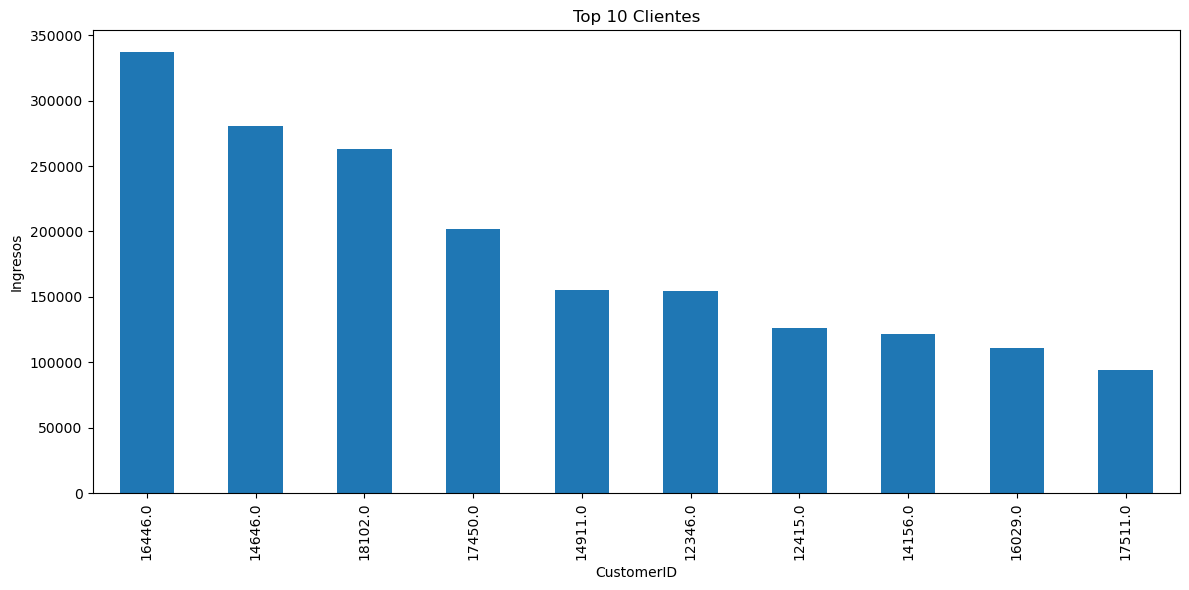

In [48]:
plt.figure(figsize=(12,6))
top_customers.plot(kind='bar')

plt.title('Top 10 Clientes')
plt.xlabel('CustomerID')
plt.ylabel('Ingresos')

plt.savefig('../imagenes/top_customers.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [53]:
df['Weekday'] = df.index.day_name()

weekday_sales = df.groupby('Weekday')['TotalPrice'].sum()

weekday_sales = weekday_sales.reindex([
   'Sunday', 'Monday','Tuesday','Wednesday','Thursday','Friday'
])

print(weekday_sales)

Weekday
Sunday        800609.591
Monday       1459741.311
Tuesday      1838075.671
Wednesday    1646194.850
Thursday     2047609.950
Friday       1730518.621
Name: TotalPrice, dtype: float64


## 📅 Ventas por Día de la Semana

Este análisis permite identificar qué días presentan mayor actividad comercial, 
lo cual es útil para optimizar campañas, promociones y operaciones del negocio.

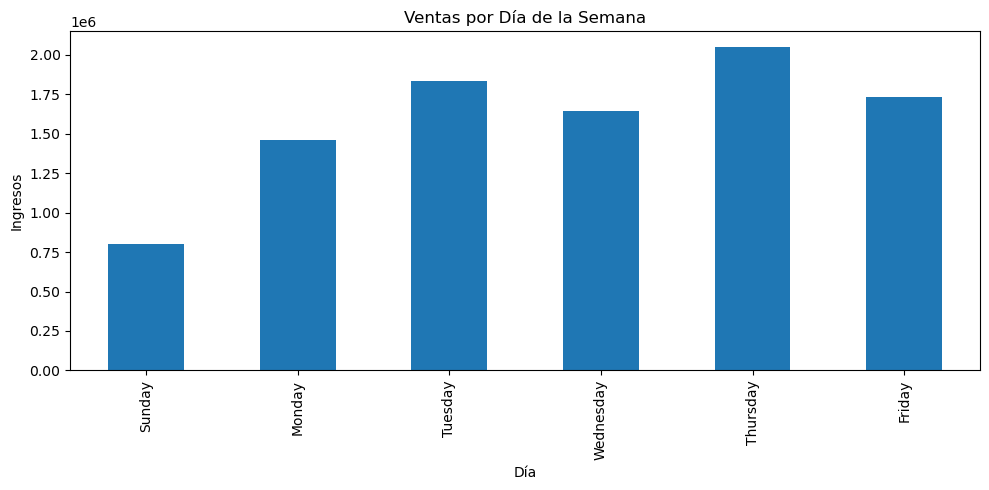

In [55]:
plt.figure(figsize=(10,5))
weekday_sales.plot(kind='bar')

plt.title('Ventas por Día de la Semana')
plt.xlabel('Día')
plt.ylabel('Ingresos')

plt.tight_layout()

plt.savefig('../imagenes/weekday_sales.png' , bbox_inches='tight')
plt.show()

# 📌 Observación:
Se identifican diferencias claras en el comportamiento de ventas según el día, 
lo que permite detectar los días más fuertes y los de menor actividad.

In [58]:
print("INSIGHTS PRINCIPALES:\n")

print("1. Las ventas presentan tendencias mensuales claras (estacionalidad).")
print("2. Un país domina la mayoría de ingresos (generalmente UK).")
print("3. Pocos clientes generan la mayor parte de las ventas.")
print("4. Algunos productos concentran gran volumen de ventas.")
print("5. Hay días de la semana con mayor actividad comercial.")

INSIGHTS PRINCIPALES:

1. Las ventas presentan tendencias mensuales claras (estacionalidad).
2. Un país domina la mayoría de ingresos (generalmente UK).
3. Pocos clientes generan la mayor parte de las ventas.
4. Algunos productos concentran gran volumen de ventas.
5. Hay días de la semana con mayor actividad comercial.


In [59]:
print("RECOMENDACIONES:\n")

print("1. Enfocar estrategias en los clientes más valiosos.")
print("2. Incrementar inventario de productos más vendidos.")
print("3. Aprovechar meses de alta demanda con campañas.")
print("4. Expandir mercado en países con menor participación.")
print("5. Crear promociones en días de baja venta.")

RECOMENDACIONES:

1. Enfocar estrategias en los clientes más valiosos.
2. Incrementar inventario de productos más vendidos.
3. Aprovechar meses de alta demanda con campañas.
4. Expandir mercado en países con menor participación.
5. Crear promociones en días de baja venta.


In [60]:
print("CONCLUSIÓN:\n")

print("El análisis permite identificar oportunidades claras de crecimiento,")
print("optimizando clientes, productos y estrategias comerciales.")

CONCLUSIÓN:

El análisis permite identificar oportunidades claras de crecimiento,
optimizando clientes, productos y estrategias comerciales.


## 🎯 Conclusión

El análisis del comportamiento de ventas permitió identificar patrones clave 
en el negocio, como la concentración de ingresos en ciertos países, 
la importancia de un grupo reducido de clientes y la alta demanda de productos específicos.

Estos hallazgos evidencian oportunidades claras para optimizar estrategias comerciales, 
mejorar la gestión de inventario y enfocar esfuerzos en los segmentos más rentables.

El uso de datos como base para la toma de decisiones permite a la empresa 
incrementar su eficiencia y potenciar su crecimiento.